In [2]:
# ==========================================================
# OptiCrop AI - Import Required Libraries
# ==========================================================

# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Display graphs inside notebook
%matplotlib inline

# Plot style
plt.style.use("ggplot")

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [3]:
# ==========================================================
# Read the Crop Recommendation Dataset
# ==========================================================

# Load the dataset
df = pd.read_csv("../dataset/Crop_recommendation.csv")

print("✅ Dataset Loaded Successfully!")

# Display the first 5 rows
df.head()

✅ Dataset Loaded Successfully!


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [4]:
# ==========================================================
# Dataset Information
# ==========================================================

print("Shape of Dataset:", df.shape)
print("\nColumn Names:\n", df.columns)

print("\nDataset Information:")
df.info()

Shape of Dataset: (2200, 8)

Column Names:
 Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='str')

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   str    
dtypes: float64(4), int64(3), str(1)
memory usage: 137.6 KB


In [5]:
# ==========================================================
# Statistical Summary
# ==========================================================

df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [6]:
# ==========================================================
# Check Missing Values
# ==========================================================

df.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [7]:
# ==========================================================
# Crop Categories
# ==========================================================

print("Total Crop Types:", df['label'].nunique())

print("\nCrop Names:")

df['label'].unique()

Total Crop Types: 22

Crop Names:


<StringArray>
[       'rice',       'maize',    'chickpea', 'kidneybeans',  'pigeonpeas',
   'mothbeans',    'mungbean',   'blackgram',      'lentil', 'pomegranate',
      'banana',       'mango',      'grapes',  'watermelon',   'muskmelon',
       'apple',      'orange',      'papaya',     'coconut',      'cotton',
        'jute',      'coffee']
Length: 22, dtype: str

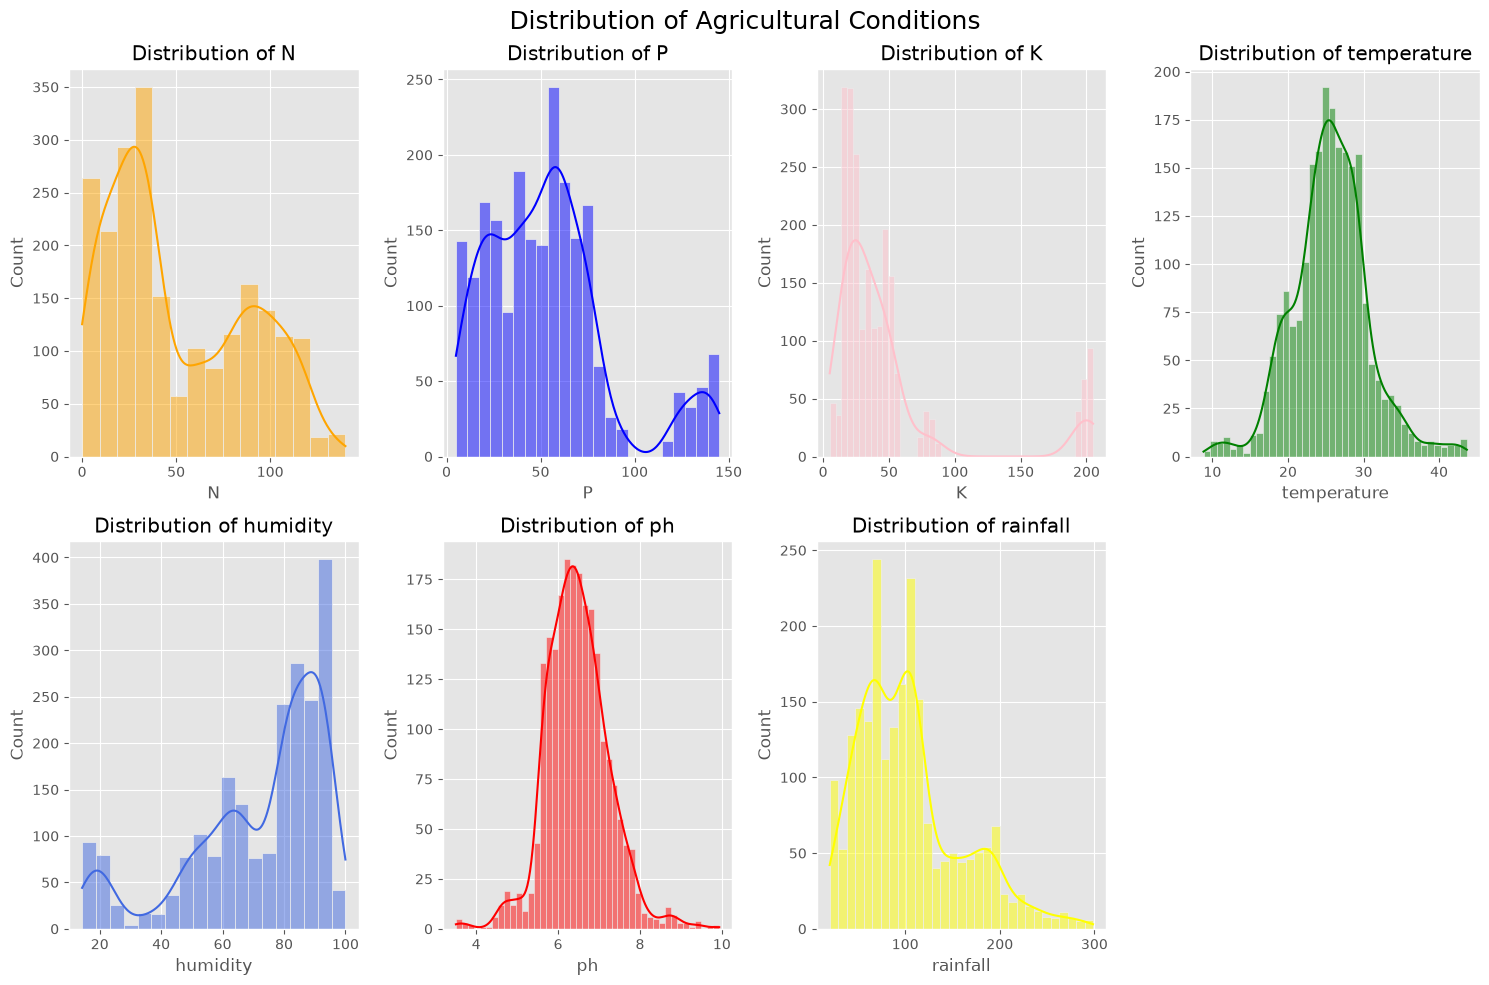

In [8]:
# ==========================================================
# Univariate Analysis
# ==========================================================

plt.figure(figsize=(15,10))

# List of numerical columns
columns = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

# Colors for each plot
colors = ['orange', 'blue', 'pink', 'green', 'royalblue', 'red', 'yellow']

# Create subplots
for i, col in enumerate(columns):
    plt.subplot(2, 4, i + 1)
    sns.histplot(df[col], kde=True, color=colors[i])
    plt.title(f"Distribution of {col}")

plt.suptitle("Distribution of Agricultural Conditions", fontsize=18)
plt.tight_layout()
plt.show()

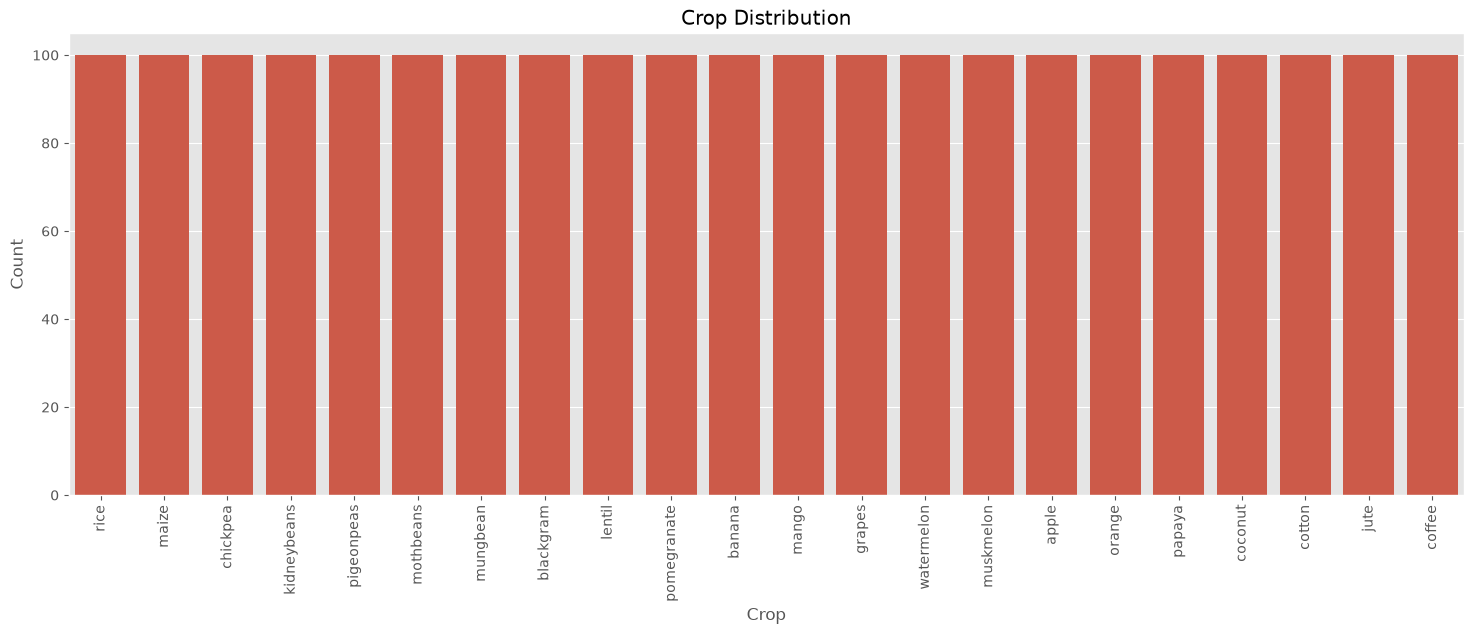

In [9]:
# ==========================================================
# Crop Distribution
# ==========================================================

plt.figure(figsize=(18,6))

sns.countplot(x='label', data=df)

plt.xticks(rotation=90)
plt.title("Crop Distribution")
plt.xlabel("Crop")
plt.ylabel("Count")

plt.show()

In [11]:
# ==========================================================
# Mean Values of Features
# ==========================================================

df[['N','P','K','temperature','humidity','ph','rainfall']].mean()

N               50.551818
P               53.362727
K               48.149091
temperature     25.616244
humidity        71.481779
ph               6.469480
rainfall       103.463655
dtype: float64

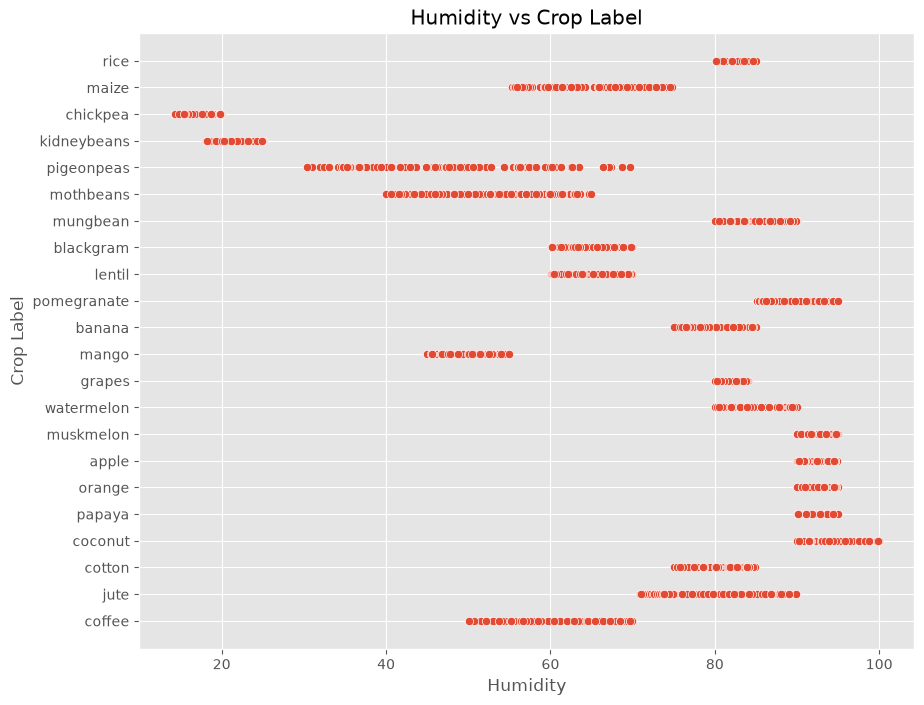

In [12]:
# ==========================================================
# Bivariate Analysis
# Humidity vs Crop Label
# ==========================================================

plt.figure(figsize=(10,8))

sns.scatterplot(x=df['humidity'], y=df['label'])

plt.title("Humidity vs Crop Label")
plt.xlabel("Humidity")
plt.ylabel("Crop Label")

plt.show()

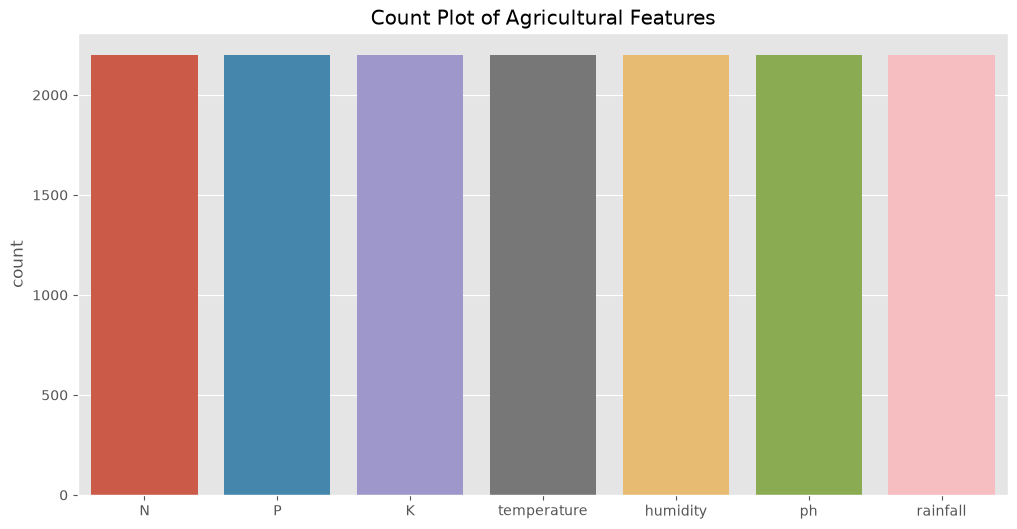

In [13]:
# ==========================================================
# Multivariate Analysis
# ==========================================================

plt.figure(figsize=(12,6))

sns.countplot(data=df)

plt.title("Count Plot of Agricultural Features")
plt.show()

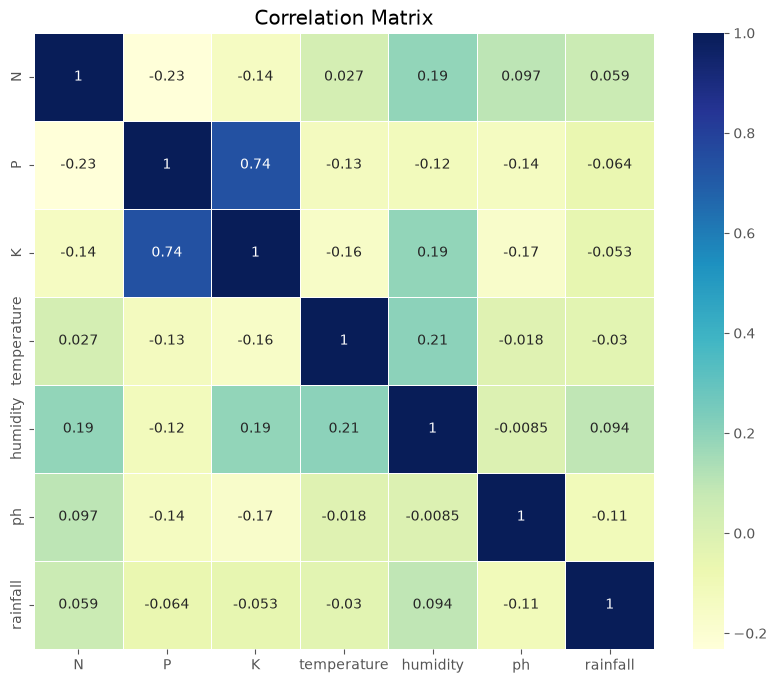

In [14]:
# ==========================================================
# Correlation Heatmap
# ==========================================================

plt.figure(figsize=(10,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="YlGnBu",
            linewidths=0.5)

plt.title("Correlation Matrix")
plt.show()

In [15]:
# ==========================================================
# Checking Dataset Shape
# ==========================================================

print("Dataset Shape:", df.shape)

Dataset Shape: (2200, 8)


In [16]:
# ==========================================================
# Dataset Information
# ==========================================================

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   str    
dtypes: float64(4), int64(3), str(1)
memory usage: 137.6 KB


In [17]:
# ==========================================================
# Checking for Null Values
# ==========================================================

df.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [18]:
# ==========================================================
# Checking Duplicate Records
# ==========================================================

print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


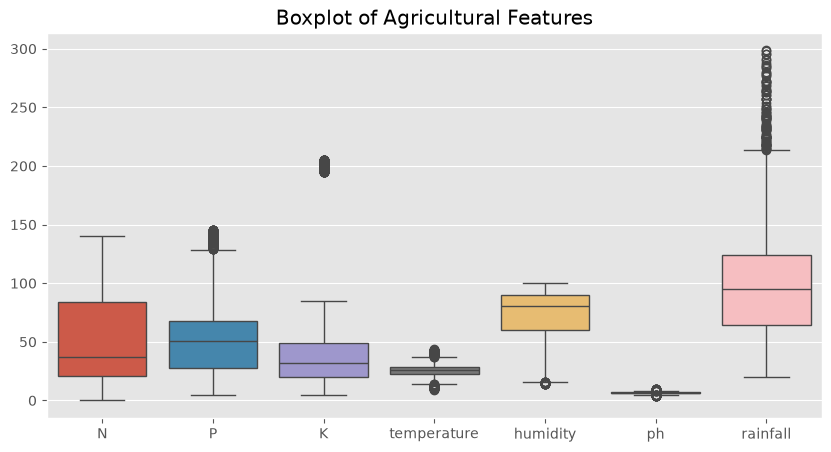

In [19]:
# ==========================================================
# Handling Outliers - Boxplot
# ==========================================================

plt.figure(figsize=(10,5))
sns.boxplot(data=df)

plt.title("Boxplot of Agricultural Features")
plt.show()


In [20]:
# ==========================================================
# Detect Outliers in Potassium (K)
# ==========================================================

Q1 = df['K'].quantile(0.25)
Q3 = df['K'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: -23.5
Upper Bound: 92.5


In [21]:
# ==========================================================
# Log Transformation for Potassium
# ==========================================================

df['K'] = np.log1p(df['K'])

print("Log transformation applied successfully!")

Log transformation applied successfully!


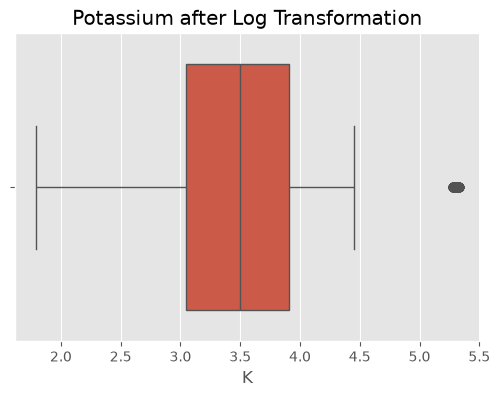

In [22]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['K'])

plt.title("Potassium after Log Transformation")
plt.show()

In [23]:
# ==========================================================
# Extracting Seasonal Crops
# ==========================================================

# Summer Crops
print("Summer Crops")
print(df[(df['temperature'] > 30) & (df['humidity'] > 50)]['label'].unique())

print("-" * 60)

# Winter Crops
print("Winter Crops")
print(df[(df['temperature'] < 20) & (df['humidity'] > 30)]['label'].unique())

print("-" * 60)

# Rainy Season Crops
print("Rainy Crops")
print(df[(df['rainfall'] > 200) & (df['humidity'] > 50)]['label'].unique())

print("-" * 60)


Summer Crops
<StringArray>
['pigeonpeas', 'mothbeans', 'blackgram', 'mango', 'grapes', 'orange',
 'papaya']
Length: 7, dtype: str
------------------------------------------------------------
Winter Crops
<StringArray>
['maize', 'pigeonpeas', 'lentil', 'pomegranate', 'grapes', 'orange']
Length: 6, dtype: str
------------------------------------------------------------
Rainy Crops
<StringArray>
['rice', 'papaya', 'coconut']
Length: 3, dtype: str
------------------------------------------------------------


In [24]:
# ==========================================================
# Splitting Features (X) and Target (y)
# ==========================================================

# Features
X = df.drop('label', axis=1)

# Target
y = df['label']

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (2200, 7)
Shape of y: (2200,)


In [25]:
# ==========================================================
# Splitting Data into Train and Test Sets
# ==========================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test :", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test :", y_test.shape)

Shape of X_train: (1760, 7)
Shape of X_test : (440, 7)
Shape of y_train: (1760,)
Shape of y_test : (440,)


In [27]:
from sklearn.cluster import KMeans


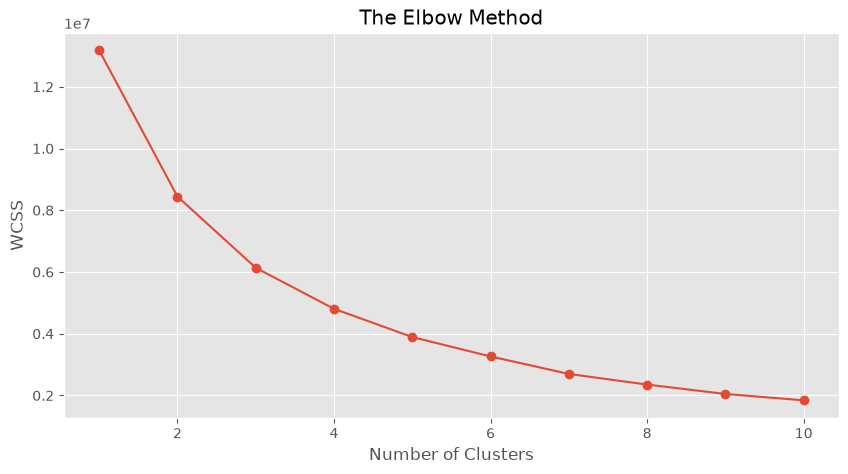

In [29]:
# ==========================================================
# K-Means Clustering - Elbow Method
# ==========================================================

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1, 11):
    km = KMeans(
        n_clusters=i,
        init='k-means++',
        max_iter=300,
        n_init=10,
        random_state=0
    )

    km.fit(X)
    wcss.append(km.inertia_)

plt.figure(figsize=(10,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("The Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()

In [31]:
# ==========================================================
# Train K-Means Model
# ==========================================================

km = KMeans(
    n_clusters=4,
    init='k-means++',
    max_iter=300,
    n_init=10,
    random_state=0
)

y_means = km.fit_predict(X)

In [32]:
# ==========================================================
# Create Cluster DataFrame
# ==========================================================

a = df["label"]

y_means = pd.DataFrame(y_means)

z = pd.concat([y_means, a], axis=1)

z.rename(columns={0: "cluster"}, inplace=True)

z.head()

,cluster,label
0,1,rice
1,1,rice
2,1,rice
3,1,rice
4,1,rice


In [33]:
# ==========================================================
# Display Clusters
# ==========================================================

print("Let's check the results after applying K-Means Clustering\n")

for i in range(4):
    print(f"Crops in Cluster {i+1}:")
    print(z[z["cluster"] == i]["label"].unique())
    print("-" * 60)

Let's check the results after applying K-Means Clustering

Crops in Cluster 1:
<StringArray>
['grapes', 'apple']
Length: 2, dtype: str
------------------------------------------------------------
Crops in Cluster 2:
<StringArray>
['rice', 'kidneybeans', 'pigeonpeas', 'papaya', 'coconut', 'jute', 'coffee']
Length: 7, dtype: str
------------------------------------------------------------
Crops in Cluster 3:
<StringArray>
['maize', 'banana', 'watermelon', 'muskmelon', 'papaya', 'cotton', 'coffee']
Length: 7, dtype: str
------------------------------------------------------------
Crops in Cluster 4:
<StringArray>
[      'maize',    'chickpea', 'kidneybeans',  'pigeonpeas',   'mothbeans',
    'mungbean',   'blackgram',      'lentil', 'pomegranate',       'mango',
      'orange',      'papaya',     'coconut']
Length: 13, dtype: str
------------------------------------------------------------


In [34]:
# ==========================================================
# Logistic Regression
# ==========================================================

from sklearn.linear_model import LogisticRegression

In [35]:
# Create Logistic Regression model
model = LogisticRegression(max_iter=1000)

# Train the model
model.fit(X_train, y_train)

print("✅ Logistic Regression model trained successfully!")

✅ Logistic Regression model trained successfully!


In [36]:
# Predict on test data

y_pred = model.predict(X_test)

print("Predictions completed successfully!")

Predictions completed successfully!


In [37]:
# ==========================================================
# Evaluating Model Performance
# ==========================================================

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        21
   blackgram       0.77      0.85      0.81        20
    chickpea       1.00      1.00      1.00        26
     coconut       1.00      1.00      1.00        27
      coffee       0.94      1.00      0.97        17
      cotton       0.85      1.00      0.92        17
      grapes       1.00      1.00      1.00        14
        jute       0.83      0.87      0.85        23
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.79      1.00      0.88        11
       maize       1.00      0.86      0.92        21
       mango       1.00      1.00      1.00        19
   mothbeans       0.95      0.88      0.91        24
    mungbean       0.90      1.00      0.95        19
   muskmelon       1.00      1.00      1.00        17
      orange       1.00      1.00      1.00        14
      papaya       0.90    

In [38]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9454545454545454


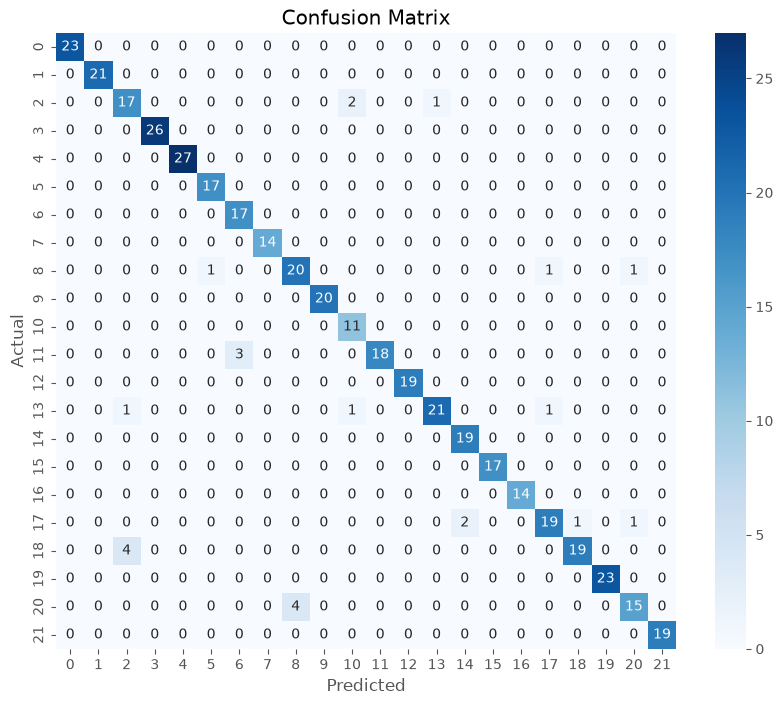

In [39]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [40]:
import pickle

pickle.dump(model, open("../models/model.pkl", "wb"))

print("✅ Model saved successfully!")

✅ Model saved successfully!


In [41]:
# ==========================================================
# Predict the Best Crop Based on Given Parameters
# ==========================================================

import pandas as pd

sample = pd.DataFrame({
    'nitrogen': [105],
    'phosphorous': [35],
    'potassium': [40],
    'temperature': [25],
    'humidity': [64],
    'ph': [7],
    'rainfall': [160]
})

prediction = model.predict(sample)

print("🌱 Recommended Crop:", prediction[0])

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- nitrogen
- phosphorous
- potassium
Feature names seen at fit time, yet now missing:
- K
- N
- P


In [42]:
print(df.columns)

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='str')


In [43]:
print(X.columns)
print(model.feature_names_in_)

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall'], dtype='str')
['N' 'P' 'K' 'temperature' 'humidity' 'ph' 'rainfall']


In [44]:
# ==========================================================
# Predict the Best Crop Based on Given Parameters
# ==========================================================

import pandas as pd

sample = pd.DataFrame({
    'N': [105],
    'P': [35],
    'K': [40],
    'temperature': [25],
    'humidity': [64],
    'ph': [7],
    'rainfall': [160]
})

prediction = model.predict(sample)

print("🌱 Recommended Crop:", prediction[0])

🌱 Recommended Crop: maize


# ==========================================================
# Epic 5: Application Building
# ==========================================================

## Building HTML Pages

The OptiCrop web application includes multiple HTML pages developed using Flask templates to provide a user-friendly interface.

### Home Page (index.html)
- Displays the project title and introduction.
- Provides navigation links to Home, About, and Find Your Crop pages.

### About Page (about.html)
- Explains the objectives of the Smart Agricultural Production Optimization Engine.
- Describes how machine learning helps recommend suitable crops based on environmental and soil conditions.

### Find Your Crop Page (predict.html)
- Contains a crop prediction form.
- Accepts user inputs:
  - Nitrogen (N)
  - Phosphorous (P)
  - Potassium (K)
  - Temperature
  - Humidity
  - pH
  - Rainfall
- Sends the input values to the Flask backend for crop prediction.

### Home Page

### About Page

In [ ]:
# ==========================================================
# OptiCrop AI - Import Required Libraries
# ==========================================================

# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Display graphs inside notebook
%matplotlib inline

# Plot style
plt.style.use("ggplot")

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


### Find Your Crop Page